In [27]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import gzip
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [29]:
def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [30]:
mnist_path = '.'

x_trainval = get_images(Path(mnist_path) / 'train-images-idx3-ubyte.gz')
y_trainval = get_labels(Path(mnist_path) / 'train-labels-idx1-ubyte.gz')
x_test = get_images(Path(mnist_path) / 't10k-images-idx3-ubyte.gz')
y_test = get_labels(Path(mnist_path) / 't10k-labels-idx1-ubyte.gz')

x_train = x_trainval[:50000].reshape(50000, -1).astype(np.float32) / 255.0
y_train = y_trainval[:50000]
x_val = x_trainval[50000:].reshape(10000, -1).astype(np.float32) / 255.0
y_val = y_trainval[50000:]
x_test = x_test.reshape(10000, -1).astype(np.float32) / 255.0

print("Train: ", x_train.shape)
print("Test: ", x_test.shape)
print("Val: ", x_val.shape)

Train:  (50000, 784)
Test:  (10000, 784)
Val:  (10000, 784)


In [31]:
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.long).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_data = MNISTDataset(x_train, y_train)
val_data = MNISTDataset(x_val, y_val)
test_data = MNISTDataset(x_test, y_test)

In [32]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch+1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        epoch_train_loss = running_loss / len(_train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        _model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                _, predicted = torch.max(val_outputs, 1)
                total_val += y_val.size(0)
                correct_val += (predicted == y_val).sum().item()

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [33]:
model = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
num_epochs = 50
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/50: 100%|██████████| 782/782 [00:03<00:00, 210.50it/s]


Epoch 1 | Train Loss: 0.3672 | Train Acc: 0.8867 | Val Loss: 0.1441 | Val Acc: 0.9580


Epoch 2/50: 100%|██████████| 782/782 [00:02<00:00, 280.41it/s]


Epoch 2 | Train Loss: 0.1748 | Train Acc: 0.9482 | Val Loss: 0.1065 | Val Acc: 0.9693


Epoch 3/50: 100%|██████████| 782/782 [00:02<00:00, 265.63it/s]


...

Epoch 48 | Train Loss: 0.1050 | Train Acc: 0.9687 | Val Loss: 0.0832 | Val Acc: 0.9742


Epoch 49/50: 100%|██████████| 782/782 [00:02<00:00, 300.01it/s]


Epoch 49 | Train Loss: 0.1094 | Train Acc: 0.9671 | Val Loss: 0.0804 | Val Acc: 0.9766


Epoch 50/50: 100%|██████████| 782/782 [00:02<00:00, 295.07it/s]


Epoch 50 | Train Loss: 0.1068 | Train Acc: 0.9683 | Val Loss: 0.0805 | Val Acc: 0.9776


In [34]:
def plot_learning_curves(_train_losses, _val_losses, _train_accuracies, _val_accuracies):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(_train_losses) + 1)

    axes[0].plot(epochs, _train_losses, label="Train Loss")
    axes[0].plot(epochs, _val_losses, label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(epochs, _train_accuracies, label="Train Accuracy")
    axes[1].plot(epochs, _val_accuracies, label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

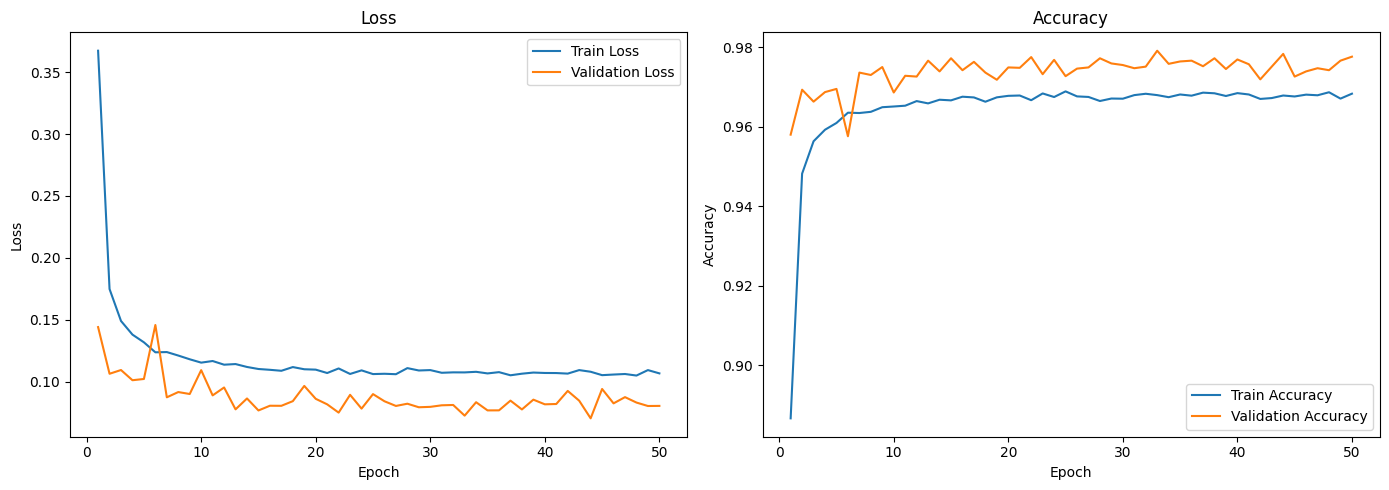

In [35]:
plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)